In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [110]:
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [111]:
pd.DataFrame(x)

,0,1
0,-0.054028,0.051973
1,-0.287680,-1.852334
2,-0.663130,1.100380
3,0.944039,-1.755304
4,-1.336571,0.824178
...,...,...
995,0.231984,2.423824
996,-0.309850,-0.758834
997,1.294138,-1.449671
998,-2.035228,-0.517227


In [112]:
pd.DataFrame(x)[0]

0     -0.054028
1     -0.287680
2     -0.663130
3      0.944039
4     -1.336571
         ...   
995    0.231984
996   -0.309850
997    1.294138
998   -2.035228
999   -2.080212
Name: 0, Length: 1000, dtype: float64

In [113]:
pd.DataFrame(x)[1]

0      0.051973
1     -1.852334
2      1.100380
3     -1.755304
4      0.824178
         ...   
995    2.423824
996   -0.758834
997   -1.449671
998   -0.517227
999   -1.252703
Name: 1, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

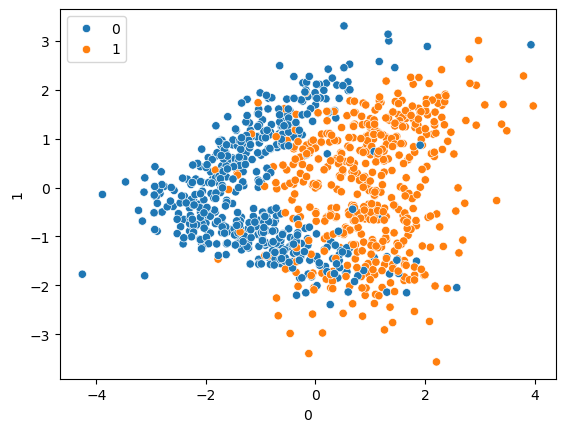

In [114]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [115]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [116]:
x_train.shape,x_test.shape

((700, 2), (300, 2))

In [117]:
from sklearn.svm import SVC

In [118]:
clf=SVC(kernel='linear')
clf

SVC(kernel='linear')

In [119]:
clf.fit(x_train,y_train)

SVC(kernel='linear')

In [120]:
clf.coef_

array([[ 1.28873222, -0.08805598]])

In [121]:
y_pred=clf.predict(x_test)

In [122]:
y_pred

array([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1])

In [123]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [124]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       139
           1       0.89      0.81      0.85       161

    accuracy                           0.84       300
   macro avg       0.84      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



In [125]:
confusion_matrix(y_test,y_pred)

array([[122,  17],
       [ 30, 131]], dtype=int64)

In [126]:
accuracy_score(y_test,y_pred)

0.8433333333333334

In [127]:
### Hyperparameter tunning with SVC

from sklearn.model_selection import GridSearchCV
params={'C':[0.1,0.2,1,2,3,10,50,100],
       'gamma':[1,0.1,0.2,0.001,0.003],
       'kernel':['linear']}

In [128]:
grid=GridSearchCV(SVC(),param_grid=params,cv=5,verbose=3)

In [129]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.850 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.814 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.850 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.850 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.829 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.850 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.814 total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.850 total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.850 total time=   0.0s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.829 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=0.2, kernel=linear;, score=0.850 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=0.2, kernel=linear

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 0.2, 1, 2, 3, 10, 50, 100],
                         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=3)

In [130]:
grid.best_params_

{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [131]:
grid.best_score_

0.8385714285714286

In [132]:
### This is the last model in GridSearchCV